# Calculadoras de Distribuições Contínuas (Versão Simplificada)

Este notebook é uma versão simplificada do original, sem o uso de widgets. 

### Como usar:
1. Execute a primeira célula (**Setup**) para importar as bibliotecas.
2. Execute a segunda célula (**Funções**) para carregar todos os motores de cálculo.
3. Vá até a distribuição desejada, altere os valores na chamada da função e execute (Shift+Enter).

## ⚙️ Setup

In [2]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo dos gráficos
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('default')
    
import warnings
warnings.filterwarnings('ignore')

## 🛠️ Funções de Cálculo
Execute esta célula uma única vez para carregar todas as funções.

In [3]:
def calcular_normal(mu=0, sigma=1, tipo='cdf', x=1.96, a=-1.96, b=1.96, p=0.95):
    if sigma <= 0: print("❌ σ > 0"); return
    dist = stats.norm(mu, sigma)
    print(f"📊 NORMAL (μ={mu}, σ={sigma})")
    if tipo == 'cdf':
        res = dist.cdf(x); print(f"P(X ≤ {x}) = {res:.6f}")
        label, x_fill = f'P(X ≤ {x})', np.linspace(mu - 4*sigma, x, 1000)
    elif tipo == 'sf':
        res = dist.sf(x); print(f"P(X ≥ {x}) = {res:.6f}")
        label, x_fill = f'P(X ≥ {x})', np.linspace(x, mu + 4*sigma, 1000)
    elif tipo == 'interval':
        res = dist.cdf(b) - dist.cdf(a); print(f"P({a} ≤ X ≤ {b}) = {res:.6f}")
        label, x_fill = f'P({a} ≤ X ≤ {b})', np.linspace(a, b, 1000)
    elif tipo == 'ppf':
        res = dist.ppf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(X ≤ x) = {p}")
        label, x_fill = f'P(X ≤ {res:.2f}) = {p}', np.linspace(mu - 4*sigma, res, 1000)
    elif tipo == 'isf':
        res = dist.isf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(X ≥ x) = {p}")
        label, x_fill = f'P(X ≥ {res:.2f}) = {p}', np.linspace(res, mu + 4*sigma, 1000)
    fig, ax = plt.subplots(figsize=(10, 4))
    x_plot = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000); y_plot = dist.pdf(x_plot)
    ax.plot(x_plot, y_plot, 'b-'); ax.fill_between(x_fill, dist.pdf(x_fill), alpha=0.3, color='blue', label=label)
    ax.legend(); plt.show()

def calcular_t(df=10, tipo='cdf', x=2.0, a=-2.0, b=2.0, p=0.05):
    if df < 1: print("❌ df ≥ 1"); return
    dist = stats.t(df)
    print(f"📊 t-STUDENT (df={df})")
    
    # Alerta de Aproximação
    if df >= 30: print(f"✅ Amostra Grande (GL={df} ≥ 30): Pode aproximar para NORMAL (Z)")
    
    if tipo == 'cdf':
        res = dist.cdf(x); print(f"P(T ≤ {x}) = {res:.6f}")
        label, x_fill = f'P(T ≤ {x})', np.linspace(-5, x, 1000)
    elif tipo == 'sf':
        res = dist.sf(x); print(f"P(T ≥ {x}) = {res:.6f}")
        label, x_fill = f'P(T ≥ {x})', np.linspace(x, 5, 1000)
    elif tipo == 'two_tailed':
        res = 2 * dist.sf(abs(x)); print(f"P(|T| ≥ {abs(x)}) = {res:.6f}")
        label = f'P(|T| ≥ {abs(x)})'
        fig, ax = plt.subplots(figsize=(10, 4))
        x_plot = np.linspace(-5, 5, 1000); y_plot = dist.pdf(x_plot)
        ax.plot(x_plot, y_plot, 'r-')
        ax.fill_between(x_plot[x_plot <= -abs(x)], dist.pdf(x_plot[x_plot <= -abs(x)]), alpha=0.3, color='red')
        ax.fill_between(x_plot[x_plot >= abs(x)], dist.pdf(x_plot[x_plot >= abs(x)]), alpha=0.3, color='red', label=label)
        ax.legend(); plt.show(); return
    elif tipo == 'ppf':
        res = dist.ppf(p); print(f"t (dado α={p}): t = {res:.6f}  |  P(T ≤ t) = {p}")
        label, x_fill = f'P(T ≤ {res:.2f}) = {p}', np.linspace(-5, res, 1000)
    elif tipo == 'isf':
        res = dist.isf(p); print(f"t (dado α={p}): t = {res:.6f}  |  P(T ≥ t) = {p}")
        label, x_fill = f'P(T ≥ {res:.2f}) = {p}', np.linspace(res, 5, 1000)
    elif tipo == 'interval':
        res = dist.cdf(b) - dist.cdf(a); print(f"P({a} ≤ T ≤ {b}) = {res:.6f}")
        label, x_fill = f'P({a} ≤ T ≤ {b})', np.linspace(a, b, 1000)
    fig, ax = plt.subplots(figsize=(10, 4))
    x_plot = np.linspace(-5, 5, 1000); y_plot = dist.pdf(x_plot)
    ax.plot(x_plot, y_plot, 'r-'); ax.fill_between(x_fill, dist.pdf(x_fill), alpha=0.3, color='red', label=label)
    ax.legend(); plt.show()

def calcular_chi2(df=5, tipo='cdf', x=7.0, a=2.0, b=10.0, p=0.05):
    if df < 1: print("❌ df ≥ 1"); return
    dist = stats.chi2(df)
    print(f"📊 QUI-QUADRADO (df={df})")
    x_max = df + 4*np.sqrt(2*df)
    if tipo == 'cdf':
        res = dist.cdf(x); print(f"P(χ² ≤ {x}) = {res:.6f}")
        label, x_fill = f'P(χ² ≤ {x})', np.linspace(0, x, 1000)
    elif tipo == 'sf':
        res = dist.sf(x); print(f"P(χ² ≥ {x}) = {res:.6f}")
        label, x_fill = f'P(χ² ≥ {x})', np.linspace(x, x_max, 1000)
    elif tipo == 'interval':
        res = dist.cdf(b) - dist.cdf(a); print(f"P({a} ≤ χ² ≤ {b}) = {res:.6f}")
        label, x_fill = f'P({a} ≤ χ² ≤ {b})', np.linspace(a, b, 1000)
    elif tipo == 'ppf':
        res = dist.ppf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(χ² ≤ x) = {p}")
        label, x_fill = f'P(χ² ≤ {res:.2f}) = {p}', np.linspace(0, res, 1000)
    elif tipo == 'isf':
        res = dist.isf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(χ² ≥ x) = {p}")
        label, x_fill = f'P(χ² ≥ {res:.2f}) = {p}', np.linspace(res, x_max, 1000)
    fig, ax = plt.subplots(figsize=(10, 4))
    x_plot = np.linspace(0, x_max, 1000); y_plot = dist.pdf(x_plot)
    ax.plot(x_plot, y_plot, color='darkorange'); ax.fill_between(x_fill, dist.pdf(x_fill), alpha=0.3, color='orange', label=label)
    ax.legend(); plt.show()

def calcular_fisher(dfn=5, dfd=10, tipo='cdf', x=2.5, a=1.0, b=4.0, p=0.05):
    dist = stats.f(dfn, dfd)
    print(f"📊 FISHER (dfn={dfn}, dfd={dfd})")
    x_max = max(6, x+2, b+1)
    if tipo == 'cdf':
        res = dist.cdf(x); print(f"P(F ≤ {x}) = {res:.6f}")
        label, x_fill = f'P(F ≤ {x})', np.linspace(0, x, 1000)
    elif tipo == 'sf':
        res = dist.sf(x); print(f"P(F ≥ {x}) = {res:.6f}")
        label, x_fill = f'P(F ≥ {x})', np.linspace(x, x_max, 1000)
    elif tipo == 'interval':
        res = dist.cdf(b) - dist.cdf(a); print(f"P({a} ≤ F ≤ {b}) = {res:.6f}")
        label, x_fill = f'P({a} ≤ F ≤ {b})', np.linspace(a, b, 1000)
    elif tipo == 'ppf':
        res = dist.ppf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(F ≤ x) = {p}")
        label, x_fill = f'P(F ≤ {res:.2f}) = {p}', np.linspace(0, res, 1000)
    elif tipo == 'isf':
        res = dist.isf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(F ≥ x) = {p}")
        label, x_fill = f'P(F ≥ {res:.2f}) = {p}', np.linspace(res, x_max, 1000)
    fig, ax = plt.subplots(figsize=(10, 4))
    x_plot = np.linspace(0.01, x_max, 1000); y_plot = dist.pdf(x_plot)
    ax.plot(x_plot, y_plot, color='purple'); ax.fill_between(x_fill, dist.pdf(x_fill), alpha=0.3, color='purple', label=label)
    ax.legend(); plt.show()

def calcular_exponencial(lam=0.5, tipo='cdf', x=2.0, a=1.0, b=4.0, p=0.05):
    if lam <= 0: print("❌ λ > 0"); return
    dist = stats.expon(scale=1/lam)
    print(f"📊 EXPONENCIAL (λ={lam})")
    x_max = max(5/lam, x+2, b+1)
    if tipo == 'cdf':
        res = dist.cdf(x); print(f"P(X ≤ {x}) = {res:.6f}")
        label, x_fill = f'P(X ≤ {x})', np.linspace(0, x, 1000)
    elif tipo == 'sf':
        res = dist.sf(x); print(f"P(X ≥ {x}) = {res:.6f}")
        label, x_fill = f'P(X ≥ {x})', np.linspace(x, x_max, 1000)
    elif tipo == 'interval':
        res = dist.cdf(b) - dist.cdf(a); print(f"P({a} ≤ X ≤ {b}) = {res:.6f}")
        label, x_fill = f'P({a} ≤ X ≤ {b})', np.linspace(a, b, 1000)
    elif tipo == 'ppf':
        res = dist.ppf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(X ≤ x) = {p}")
        label, x_fill = f'P(X ≤ {res:.2f}) = {p}', np.linspace(0, res, 1000)
    elif tipo == 'isf':
        res = dist.isf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(X ≥ x) = {p}")
        label, x_fill = f'P(X ≥ {res:.2f}) = {p}', np.linspace(res, x_max, 1000)
    fig, ax = plt.subplots(figsize=(10, 4))
    x_plot = np.linspace(0, x_max, 1000); y_plot = dist.pdf(x_plot)
    ax.plot(x_plot, y_plot, color='teal'); ax.fill_between(x_fill, dist.pdf(x_fill), alpha=0.3, color='teal', label=label)
    ax.legend(); plt.show()

def calcular_uniforme(a_min=0, b_max=10, tipo='cdf', x=5.0, a=2.0, b=8.0, p=0.5):
    if b_max <= a_min: print("❌ b > a"); return
    dist = stats.uniform(loc=a_min, scale=b_max-a_min)
    print(f"📊 UNIFORME [ {a_min}, {b_max} ]")
    if tipo == 'cdf':
        res = dist.cdf(x); print(f"P(X ≤ {x}) = {res:.6f}")
        label, x_fill = f'P(X ≤ {x})', np.linspace(a_min, x, 1000)
    elif tipo == 'sf':
        res = dist.sf(x); print(f"P(X ≥ {x}) = {res:.6f}")
        label, x_fill = f'P(X ≥ {x})', np.linspace(x, b_max, 1000)
    elif tipo == 'interval':
        res = dist.cdf(b) - dist.cdf(a); print(f"P({a} ≤ X ≤ {b}) = {res:.6f}")
        label, x_fill = f'P({a} ≤ X ≤ {b})', np.linspace(a, b, 1000)
    elif tipo == 'ppf':
        res = dist.ppf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(X ≤ x) = {p}")
        label, x_fill = f'P(X ≤ {res:.2f}) = {p}', np.linspace(a_min, res, 1000)
    elif tipo == 'isf':
        res = dist.isf(p); print(f"x (dado α={p}): x = {res:.6f}  |  P(X ≥ x) = {p}")
        label, x_fill = f'P(X ≥ {res:.2f}) = {p}', np.linspace(res, b_max, 1000)
    fig, ax = plt.subplots(figsize=(10, 4))
    x_plot = np.linspace(a_min-1, b_max+1, 1000); y_plot = dist.pdf(x_plot)
    ax.plot(x_plot, y_plot, color='darkgreen'); ax.fill_between(x_fill, dist.pdf(x_fill), alpha=0.3, color='green', label=label)
    ax.legend(); plt.show()

## 1. Distribuição Normal

📊 NORMAL (μ=2600, σ=50.99019513592785)
P(X ≤ 2500) = 0.024930


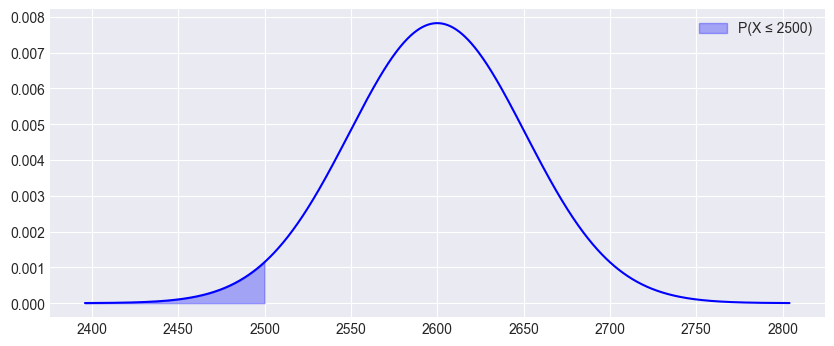

In [10]:
# REMOVA O # ANTES DE calcular_normal() para executar
# calcular_normal(
#     mu = 2600,         # média
#     sigma = 2600**(1/2),      # desvio padrão
#     tipo = 'cdf',   # Opções: 'cdf' (≤), 'sf' (≥), 'interval' (a≤X≤b), 'ppf' (Inverso cdf), 'isf' (Inverso sf)
#     x = 2500,       # valor x para cdf e sf
#     a = -1.96,      # limite inferior para interval
#     b = 1.96,       # limite superior para interval
#     p = 0.02        # probabilidade acumulada (α) para ppf e isf
# )

## 2. Distribuição t de Student

📊 t-STUDENT (df=10)
P(T ≤ 2.0) = 0.963306


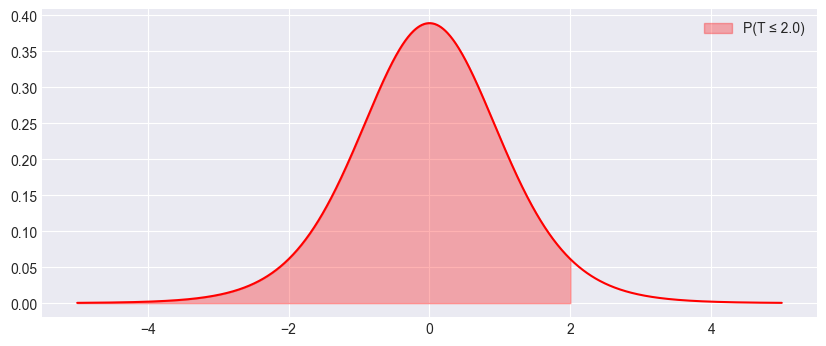

In [5]:
# REMOVA O # ANTES DE calcular_t() para executar
# calcular_t(
#     df = 10,        # graus de liberdade
#     tipo = 'cdf',   # Opções: 'cdf' (≤), 'sf' (≥), 'two_tailed' (bilateral), 'interval' (a≤T≤b), 'ppf', 'isf'
#     x = 2.0,        # valor t para cdf, sf e bilateral
#     a = -2.0,       # limite inferior para interval
#     b = 2.0,        # limite superior para interval
#     p = 0.05        # probabilidade (α) para ppf e isf
# )

## 3. Distribuição Qui-Quadrado (χ²)

📊 QUI-QUADRADO (df=5)
P(χ² ≥ 7.0) = 0.220640


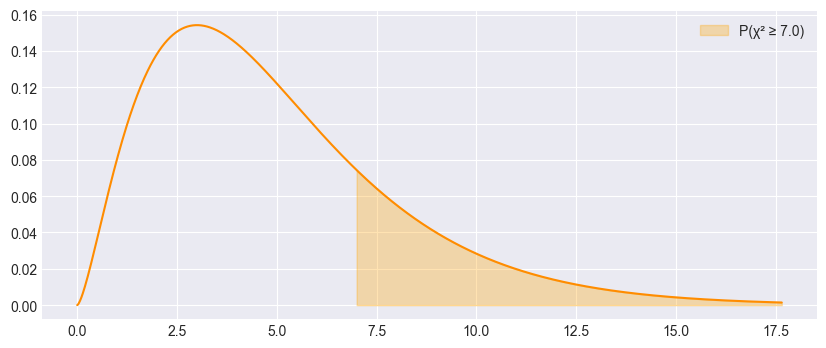

In [6]:
# REMOVA O # ANTES DE calcular_chi2() para executar
# calcular_chi2(
#     df = 5,         # graus de liberdade
#     tipo = 'sf',    # Opções: 'cdf' (≤), 'sf' (≥), 'interval' (a≤X≤b), 'ppf', 'isf'
#     x = 7.0,        # valor x para cdf e sf
#     a = 2.0,        # limite inferior para interval
#     b = 10.0,       # limite superior para interval
#     p = 0.05        # probabilidade (α) para ppf e isf
# )

## 4. Distribuição F (Fisher)

📊 FISHER (dfn=5, dfd=10)
P(F ≥ 2.5) = 0.102002


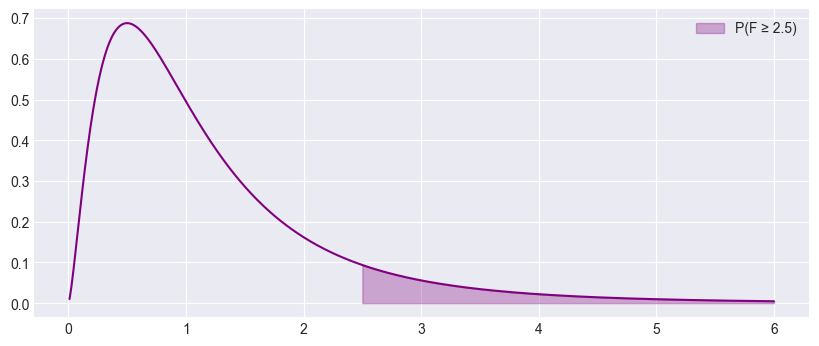

In [ ]:
# REMOVA O # ANTES DE calcular_fisher() para executar
# calcular_fisher(
#     dfn = 5,        # graus de liberdade do numerador
#     dfd = 10,       # graus de liberdade do denominador
#     tipo = 'sf',    # Opções: 'cdf' (≤), 'sf' (≥), 'interval' (a≤F≤b), 'ppf', 'isf'
#     x = 2.5,        # valor F para cdf e sf
#     a = 1.0,        # limite inferior para interval
#     b = 4.0,        # limite superior para interval
#     p = 0.05        # probabilidade (α) para ppf e isf
# )

## 5. Distribuição Exponencial

📊 EXPONENCIAL (λ=0.5)
P(X ≤ 2.0) = 0.632121


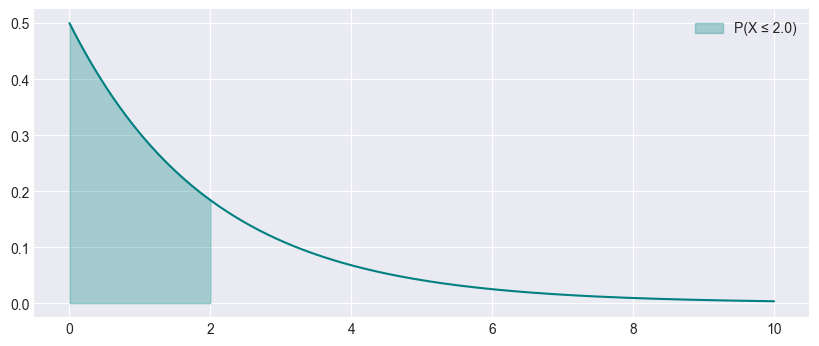

In [ ]:
# REMOVA O # ANTES DE calcular_exponencial() para executar
# calcular_exponencial(
#     lam = 0.5,      # taxa λ
#     tipo = 'cdf',   # Opções: 'cdf' (≤), 'sf' (≥), 'interval' (a≤X≤b), 'ppf', 'isf'
#     x = 2.0,        # valor x para cdf e sf
#     a = 1.0,        # limite inferior para interval
#     b = 4.0,        # limite superior para interval
#     p = 0.05        # probabilidade (α) para ppf e isf
# )

## 6. Distribuição Uniforme Contínua

📊 UNIFORME [ 0, 10 ]
P(X ≤ 5.0) = 0.500000


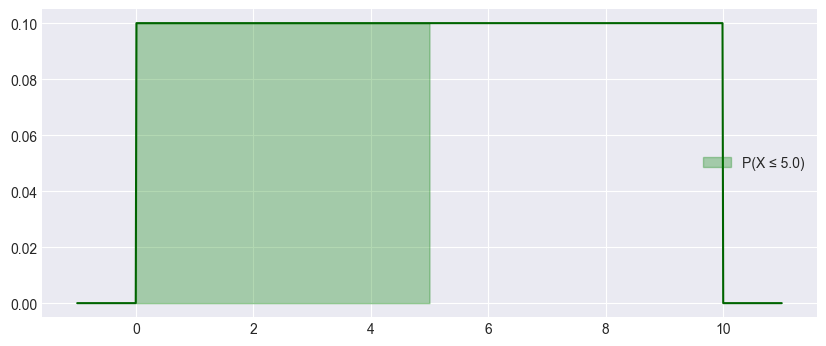

In [ ]:
# REMOVA O # ANTES DE calcular_uniforme() para executar
# calcular_uniforme(
#     a_min = 0,      # limite inferior da distribuição
#     b_max = 10,     # limite superior da distribuição
#     tipo = 'cdf',   # Opções: 'cdf' (≤), 'sf' (≥), 'interval' (a≤X≤b), 'ppf', 'isf'
#     x = 5.0,        # valor x para cdf e sf
#     a = 2.0,        # limite inferior para interval
#     b = 8.0,        # limite superior para interval
#     p = 0.5         # probabilidade (α) para ppf e isf
# )